In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 15-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)


(18393, 202)


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

(18393, 679)


## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 70% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.7083446588746942

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.70      0.71      1828
           1       0.71      0.71      0.71      1851

    accuracy                           0.71      3679
   macro avg       0.71      0.71      0.71      3679
weighted avg       0.71      0.71      0.71      3679



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
168,level_diff,0.088565
173,networth_ratio,0.081390
166,networth_diff,0.033007
170,kdr_diff,0.012731
163,team1_team_kdr,0.010693
...,...,...
187,team0_p1_hero_14,0.000000
189,team0_p1_hero_16,0.000000
190,team0_p1_hero_17,0.000000
191,team0_p1_hero_18,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.6977439521609133

Random Forest Report:

              precision    recall  f1-score   support

           0       0.70      0.69      0.70      1828
           1       0.70      0.70      0.70      1851

    accuracy                           0.70      3679
   macro avg       0.70      0.70      0.70      3679
weighted avg       0.70      0.70      0.70      3679



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
173                    networth_ratio    0.053453
166                     networth_diff    0.052348
168                        level_diff    0.036112
171                          gpm_diff    0.035512
163                    team1_team_kdr    0.025801
170                          kdr_diff    0.023176
162                    team0_team_kdr    0.022583
169                        carry_diff    0.017053
2           team0_team_total_networth    0.015902
175                   objective_ratio    0.015842
172                    objective_diff    0.014433
174                      damage_ratio    0.013970
85         team1_team_gold_per_minute    0.012925
6          team0_team_gold_per_minute    0.012885
167                       damage_diff    0.012610
5                team0_team_avg_level    0.011235
81          team1_team_total_networth    0.010417
58                  team0_p5_networth    0.010332
4    team0_team_total_objectivedamage    0.009042


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.7029083990214732

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.69      0.70      1828
           1       0.70      0.71      0.71      1851

    accuracy                           0.70      3679
   macro avg       0.70      0.70      0.70      3679
weighted avg       0.70      0.70      0.70      3679



The tuned model achives ~70.2% test accuracy and ~77% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.770354764170178
0.7029083990214732


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.781.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.7814300212671133


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 70.6% test accuracy and 0.782 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6896714	total: 143ms	remaining: 3m 33s
100:	learn: 0.5812491	total: 1s	remaining: 13.9s
200:	learn: 0.5704688	total: 1.78s	remaining: 11.5s
300:	learn: 0.5658174	total: 2.54s	remaining: 10.1s
400:	learn: 0.5626371	total: 3.27s	remaining: 8.97s
500:	learn: 0.5591268	total: 3.98s	remaining: 7.94s
600:	learn: 0.5531633	total: 4.71s	remaining: 7.04s
700:	learn: 0.5453908	total: 5.47s	remaining: 6.24s
800:	learn: 0.5378769	total: 6.21s	remaining: 5.42s
900:	learn: 0.5308742	total: 6.93s	remaining: 4.61s
1000:	learn: 0.5241153	total: 7.68s	remaining: 3.83s
1100:	learn: 0.5177147	total: 8.42s	remaining: 3.05s
1200:	learn: 0.5114110	total: 9.14s	remaining: 2.28s
1300:	learn: 0.5053396	total: 9.86s	remaining: 1.51s
1400:	learn: 0.4996623	total: 10.6s	remaining: 746ms
1499:	learn: 0.4939924	total: 11.2s	remaining: 0us
Accuracy for CAT: 0.7064419679260668

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.71      0.70      18

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.7596166915862443
0.7064419679260668


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 70.3% accuracy and 0.782 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))
print(roc_auc_score(y_test, probs[:, 1]))

0.7034520250067954
0.7828508334840591


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic', cv=5)

calibrated.fit(X_train, y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.7816405940605764


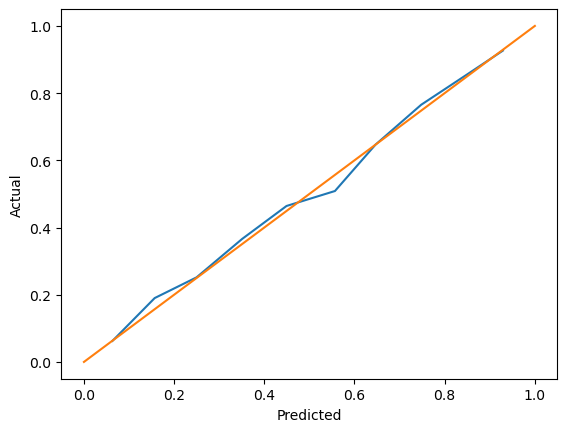

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

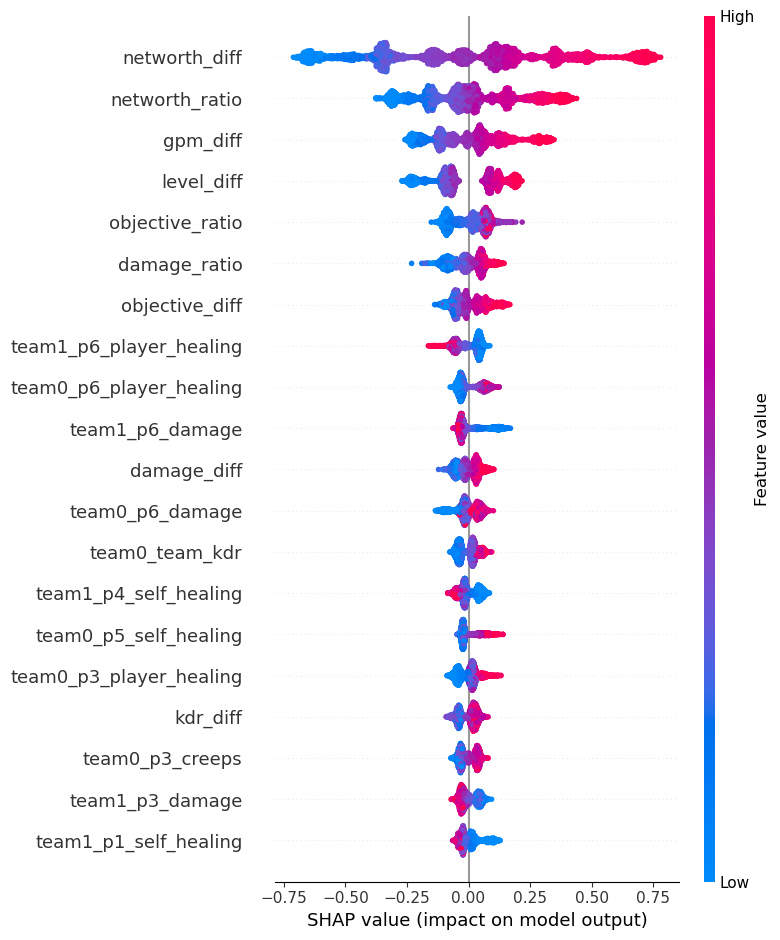

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values( X_test))

shap.summary_plot(shap_values, X_test)

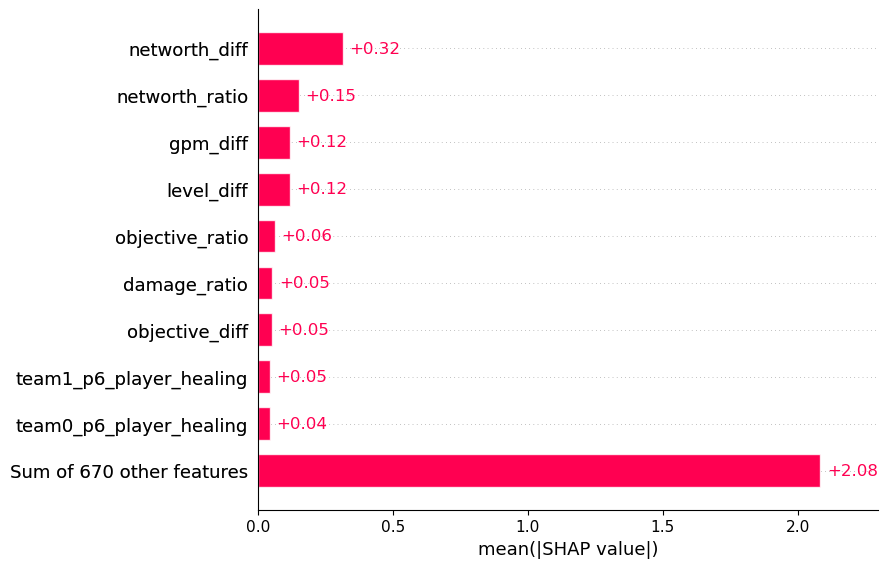

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))